In [1]:
import os
from dotenv import load_dotenv
ROOT = "../" # Base directory relative to this notebook's location. Adjust if the notebook is moved
CSV_DIR = os.path.join(ROOT, "csv", "historical-data")
JSON_DIR = os.path.join(ROOT, "json")
DOTENV_PATH = os.path.join(ROOT, '../../apis/.env') # Adjust to .env file location
if load_dotenv(DOTENV_PATH):
    abs_path = os.path.abspath(DOTENV_PATH)
    drive, rel = os.path.splitdrive(abs_path)
    parts = rel.strip(os.sep).split(os.sep)
    masked = parts.copy()
    masked_parts = 1  # adjust to mask parts of your path
    max_maskable = max(0, len(parts) - 2)
    for i in range(min(masked_parts, max_maskable)):
        idx = len(parts) - 3 - i
        masked[idx] = "***"
    prefix = f"{drive}{os.sep}" if drive else (os.sep if abs_path.startswith(os.sep) else "")
    print(f"Loaded .env from {prefix}{os.sep.join(masked)}")
else:
    print("Failed to load .env file.")

API_KEY = os.getenv("AEMET_API_KEY")

def mask_token(token, unmasked_chars=3):
    return token[:unmasked_chars] + '*' * (len(token) - unmasked_chars*2) + token[-unmasked_chars:]
print(f"AEMET_API_KEY: {mask_token(API_KEY)}")

# Variables de ejecución avanzadas (no es necesario cambiarlas si no se ha alterado la estructura de ficheros del proyecto):
DB_FILE = "db/thematic_screener.db" # Sólo necesario si DOWNLOAD_REMOTE_DB = False
import sys
sys.path.append(ROOT)

from src.aemet_helpers import AemetClient
from src.weather_data_download import download_station_data, cast_columns
import pandas as pd
import json
import matplotlib.pyplot as plt
import time

Loaded .env from /home/***/apis/.env
AEMET_API_KEY: eyJ***********************************************************************************************************************************************************************************************************************************************************************************************************rF4


In [2]:
locations_dict = os.path.join(JSON_DIR, "locations.json")
with open(locations_dict, "r", encoding="utf-8") as f:
    locations_df = pd.DataFrame(
        list(json.load(f).items()),
        columns=["code", "location"]
    )

display(locations_df.sample(5))

,code,location
8,0092X,BERGA INSTITUTO
200,2507Y,RUEDA
226,2828Y,BARCO DE AVILA
538,8155Y,MOTILLA DEL PALANCAR
83,1179B,CARREÑA DE CABRALES


### Test download

In [12]:
client = AemetClient(API_KEY)
station_id = "9698U"
df = download_station_data(client, station_id=station_id, start_date="2020-01-01", max_retries=3, sleep_seconds=8)

Fetching data for station 9698U from 2020-01-01 to 2020-06-29...
✗ Error: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response')) (Retry 1/3)
Fetching data for station 9698U from 2020-01-01 to 2020-06-29...
✗ Error: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response')) (Retry 2/3)
Fetching data for station 9698U from 2020-01-01 to 2020-06-29...
✓ Retrieved 170 records (from 2020-01-01 to 2020-06-29)
Fetching data for station 9698U from 2020-06-30 to 2020-12-27...
✗ Error: 429 Client Error: Too Many Requests for url: https://opendata.aemet.es/opendata/api/valores/climatologicos/diarios/datos/fechaini/2020-06-30T00:00:00UTC/fechafin/2020-12-27T00:00:00UTC/estacion/9698U (Retry 1/3)
Fetching data for station 9698U from 2020-06-30 to 2020-12-27...
✗ Error: 429 Client Error: Too Many Requests for url: https://opendata.aemet.es/opendata/api/valores/climatologicos/diarios/datos/fechaini/2020-06-30T00:00:00UTC/fechafin

In [13]:
display(df.head(3))
print("...")
display(df.tail(3))

,fecha,indicativo,nombre,provincia,altitud,tmed,prec,tmin,horatmin,tmax,...,sol,presMax,horaPresMax,presMin,horaPresMin,hrMedia,hrMax,horaHrMax,hrMin,horaHrMin
0,2020-01-01,9698U,TALARN,LLEIDA,807,"-0,6","0,0","-2,8",22:40,"1,5",...,"0,0","937,6",10,"935,2",14,NaN,NaN,NaN,NaN,NaN
1,2020-01-02,9698U,TALARN,LLEIDA,807,"0,1","0,0","-4,0",06:40,"4,2",...,"4,7","936,7",10,"934,4",15,100,NaN,NaN,NaN,NaN
2,2020-01-03,9698U,TALARN,LLEIDA,807,"0,8","0,0","-3,0",23:59,"4,7",...,"4,1","937,1",23,"934,2",14,90,99,Varias,75,00:00


...


,fecha,indicativo,nombre,provincia,altitud,tmed,prec,tmin,horatmin,tmax,...,sol,presMax,horaPresMax,presMin,horaPresMin,hrMedia,hrMax,horaHrMax,hrMin,horaHrMin
1744,2024-12-08,9698U,TALARN,LLEIDA,807,NaN,"0,0",NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1745,2024-12-09,9698U,TALARN,LLEIDA,807,NaN,"0,0",NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1746,2024-12-10,9698U,TALARN,LLEIDA,807,NaN,"0,0",NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
schema_path = os.path.join(JSON_DIR, "data-fields.json")
df = cast_columns(df, schema_path)
print("\nColumn types:")
for col in df.columns:
    print(f"{col}: {df[col].dtype}")


Column types:
fecha: datetime64[ns]
indicativo: string
nombre: string
provincia: string
altitud: Int64
tmed: Float64
prec: Float64
tmin: Float64
horatmin: string
tmax: Float64
horatmax: string
dir: Int64
velmedia: Float64
racha: Float64
horaracha: string
sol: object
presMax: object
horaPresMax: object
presMin: object
horaPresMin: object
hrMedia: Int64
hrMax: Int64
horaHrMax: string
hrMin: Int64
horaHrMin: string


In [15]:
df.to_csv(os.path.join(CSV_DIR,"test-downloads", f"test_{station_id}_hist.csv"), index=False)

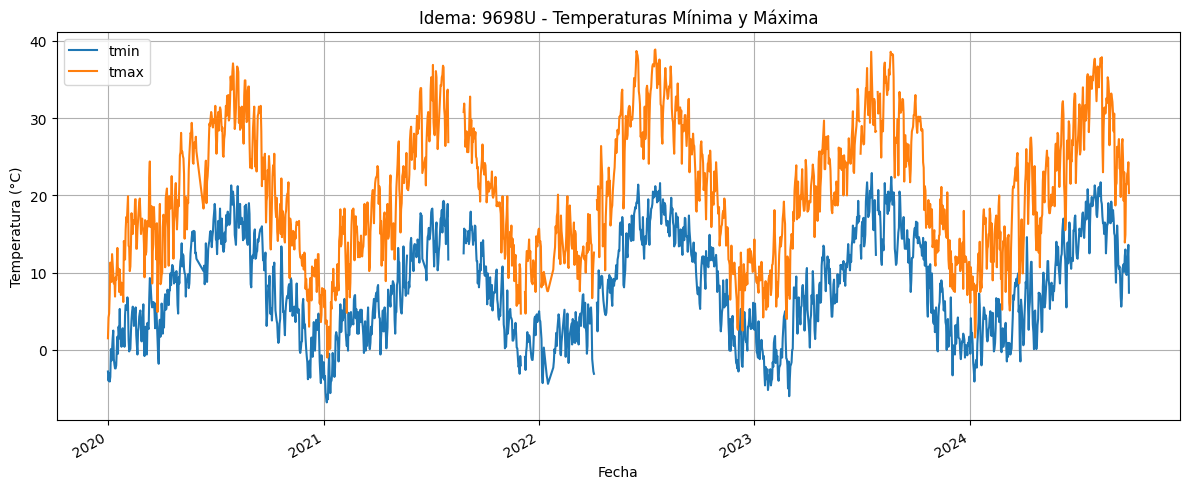

In [16]:
ax = df.sort_values("fecha").plot(x="fecha", y=["tmin", "tmax"], kind="line", figsize=(12,5))
ax.set_xlabel("Fecha")
ax.set_ylabel("Temperatura (°C)")
ax.set_title(f"Idema: {station_id} - Temperaturas Mínima y Máxima")
ax.grid(True)
plt.tight_layout()
plt.show()

### All locations

Shuffling the dataframe:

In [3]:
locations_df = locations_df.sample(frac=1).reset_index(drop=True)
display(locations_df)

,code,location
0,7007Y,MAZARRÓN/LAS TORRES
1,4489X,ALCONCHEL (AUTOMATICA)
2,B825B,MERCADAL
3,C148F,SAUCES-S.ANDRÉS-BALSA ADEYAHAME
4,1111X,SANTANDER CMT
...,...,...
816,0367,GIRONA AEROPUERTO
817,2444,ÁVILA
818,1025X,BEASAIN ARRIARAN
819,0076,BARCELONA AEROPUERTO


In [4]:
client = AemetClient(API_KEY)
schema_path = os.path.join(JSON_DIR, "data-fields.json")
max_downloads = 20

downloads = 0
for station_id in locations_df["code"].astype(str).unique():
    # stop early if max_downloads is set and already reached
    if max_downloads is not None and downloads >= int(max_downloads):
        print(f"Reached max_downloads ({max_downloads}); stopping.")
        break

    out_path = os.path.join(CSV_DIR, f"{station_id}_hist.csv")
    if os.path.exists(out_path):
        print(f"Skipping {station_id}: file exists")
        continue
    try:
        df_loc = download_station_data(client, station_id=station_id, start_date="2021-01-01", max_retries=8, sleep_seconds=7)
        if df_loc is None or df_loc.empty:
            print(f"No data for {station_id}")
            continue
        df_loc = cast_columns(df_loc, schema_path)
        df_loc.to_csv(out_path, index=False)
        downloads += 1
        print(f"Saved {out_path} ({downloads} downloads)")
    except Exception as e:
        print(f"Error downloading {station_id}: {e}")

    # check again after a successful download
    if max_downloads is not None and downloads >= int(max_downloads):
        print(f"Reached max_downloads ({max_downloads}); stopping.")
        break

    time.sleep(3)

Fetching data for station 7007Y from 2021-01-01 to 2021-06-29...
✓ Retrieved 180 records (from 2021-01-01 to 2021-06-29)
Fetching data for station 7007Y from 2021-06-30 to 2021-12-26...
✗ Error: 429 Client Error: Too Many Requests for url: https://opendata.aemet.es/opendata/api/valores/climatologicos/diarios/datos/fechaini/2021-06-30T00:00:00UTC/fechafin/2021-12-26T00:00:00UTC/estacion/7007Y (Retry 1/8)
Fetching data for station 7007Y from 2021-06-30 to 2021-12-26...
✗ Error: 429 Client Error: Too Many Requests for url: https://opendata.aemet.es/opendata/api/valores/climatologicos/diarios/datos/fechaini/2021-06-30T00:00:00UTC/fechafin/2021-12-26T00:00:00UTC/estacion/7007Y (Retry 2/8)
Fetching data for station 7007Y from 2021-06-30 to 2021-12-26...
✓ Retrieved 180 records (from 2021-06-30 to 2021-12-26)
Fetching data for station 7007Y from 2021-12-27 to 2022-06-24...
✓ Retrieved 180 records (from 2021-12-27 to 2022-06-24)
Fetching data for station 7007Y from 2022-06-25 to 2022-12-21...
